In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib as mpl
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

import argparse
import os

import fsspec
import numpy as np
import pandas as pd
import xarray as xr
import goes2go
import pandas as pd
from tqdm import tqdm

from pyproj import Proj
from scipy.interpolate import make_splrep

In [2]:
ibtracs_file = '/home/users/annaju/eo-data-prep/notebooks/IBTrACs/ibtracs.ALL.list.v04r01.csv'
ibtracs_na_file = '/home/users/annaju/eo-data-prep/notebooks/IBTrACs/ibtracs.NA.list.v04r01.csv'
ibtracs_ep_file = '/home/users/annaju/eo-data-prep/notebooks/IBTrACs/ibtracs.EP.list.v04r01.csv'
ibtracs_wp_file = '/home/users/annaju/eo-data-prep/notebooks/IBTrACs/ibtracs.WP.list.v04r01.csv'
ibtracs_sp_file = '/home/users/annaju/eo-data-prep/notebooks/IBTrACs/ibtracs.SP.list.v04r01.csv'
ibtracs_si_file = '/home/users/annaju/eo-data-prep/notebooks/IBTrACs/ibtracs.SI.list.v04r01.csv'
ibtracs_sa_file = '/home/users/annaju/eo-data-prep/notebooks/IBTrACs/ibtracs.SA.list.v04r01.csv'
ibtracs_ni_file = '/home/users/annaju/eo-data-prep/notebooks/IBTrACs/ibtracs.NI.list.v04r01.csv'

In [3]:
df = pd.read_csv(ibtracs_file)
df_na = pd.read_csv(ibtracs_na_file)
df_ep = pd.read_csv(ibtracs_ep_file)
df_wp = pd.read_csv(ibtracs_wp_file)
df_sp = pd.read_csv(ibtracs_sp_file)
df_si = pd.read_csv(ibtracs_si_file)
df_sa = pd.read_csv(ibtracs_sa_file)
df_ni = pd.read_csv(ibtracs_ni_file)

/tmp/ipykernel_2787961/3797323616.py:1: DtypeWarning: Columns (1,2,8,9,14,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ibtracs_file)
/tmp/ipykernel_2787961/3797323616.py:2: DtypeWarning: Columns (1,2,3,8,9,14,19,20,23,24,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df_na = pd.read_csv(ibtracs_na_file)
/tmp/ipykernel_2787961/3797323616.py:3: DtypeWarning: Columns (1,2,8,9,14,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ep = pd.read_csv(ibtracs_ep_file)
/tmp/ipykernel_2787961/3797323616.py:4: DtypeWarning: Columns (1,2,8,9,14,142,143,144,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df_wp = pd.read_csv(ibtracs_wp_file)
/tmp/ipykernel_2787961/3797323616.py:5: DtypeWarning: Columns (1,2,8,9,14,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sp = pd.read_csv(ibtracs_sp_file)


### North Indian Files

In [6]:
df_ni_filtered = df_ni[df_ni.SEASON.isin(np.arange(2004, 2025).tolist())]
df_ni_filtered = df_ni_filtered[df_ni_filtered.NATURE.isin(['TS', 'DS'])]
df_ni_filtered = df_ni_filtered[df_ni_filtered.NAME != 'UNNAMED']
# filter for GOES FOV
df_ni_filtered = df_ni_filtered[df_ni_filtered.LAT.between(-50, 50) & df_ni_filtered.LON.between(-50, 50)]

# filter out storms with less than 8 points
grouped = df_ni_filtered.groupby('SID')
lengths = grouped.size()
df_ni_filtered = df_ni_filtered[df_ni_filtered.SID.isin(lengths[lengths >= 8].index)]

In [7]:
len(df_ni_filtered.SID.unique())

4

In [8]:
df_ni_filtered.LAT.min(), df_ni_filtered.LAT.max(), df_ni_filtered.LON.min(), df_ni_filtered.LON.max()

(9.3, 14.8, 42.9, 50.0)

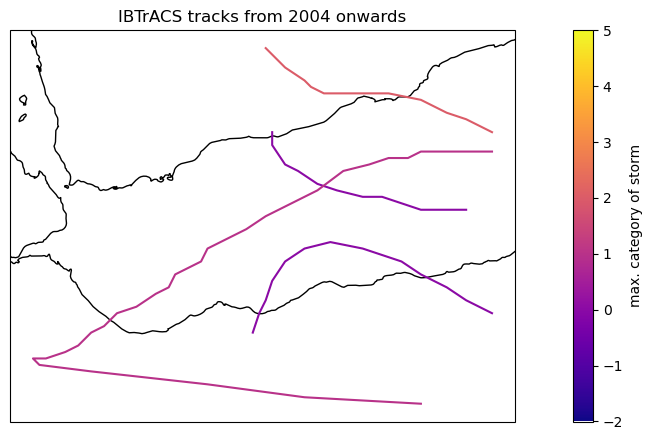

In [9]:
# Plot tracks on map
fig, ax = plt.subplots(figsize=(12, 4.5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
grouped = df_ni_filtered.groupby('SID')

# plot every track with colour for category
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=-2, vmax=5)
for i, (name, group) in enumerate(grouped):
    max_cat = group['USA_SSHS'].max()
    ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color=cmap(norm(max_cat)))

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for ScalarMappable with colorbar
plt.colorbar(sm, ax=ax, label='max. category of storm')
plt.title('IBTrACS tracks from 2004 onwards')

plt.tight_layout()

### South Indian Files

In [10]:
df_si_filtered = df_si[df_si.SEASON.isin(np.arange(2004, 2025).tolist())]
df_si_filtered = df_si_filtered[df_si_filtered.NATURE.isin(['TS', 'DS'])]
df_si_filtered = df_si_filtered[df_si_filtered.NAME != 'UNNAMED']
# filter for GOES FOV
df_si_filtered = df_si_filtered[df_si_filtered.LAT.between(-50, 50) & df_si_filtered.LON.between(-125, -25)]

# filter out storms with less than 8 points
grouped = df_si_filtered.groupby('SID')
lengths = grouped.size()
df_si_filtered = df_si_filtered[df_si_filtered.SID.isin(lengths[lengths >= 8].index)]

In [11]:
len(df_si_filtered.SID.unique())

0

### Eastern Pacific Files

In [12]:
df_ep_filtered = df_ep[df_ep.SEASON.isin(np.arange(2004, 2025).tolist())]
df_ep_filtered = df_ep_filtered[df_ep_filtered.NATURE.isin(['TS', 'DS'])]
df_ep_filtered = df_ep_filtered[df_ep_filtered.NAME != 'UNNAMED']
# filter for GOES FOV
df_ep_filtered = df_ep_filtered[df_ep_filtered.LAT.between(-50, 50) & df_ep_filtered.LON.between(-50, 50)]

# filter out storms with less than 8 points
grouped = df_ep_filtered.groupby('SID')
lengths = grouped.size()
df_ep_filtered = df_ep_filtered[df_ep_filtered.SID.isin(lengths[lengths >= 8].index)]

In [13]:
len(df_ep_filtered.SID.unique())

0